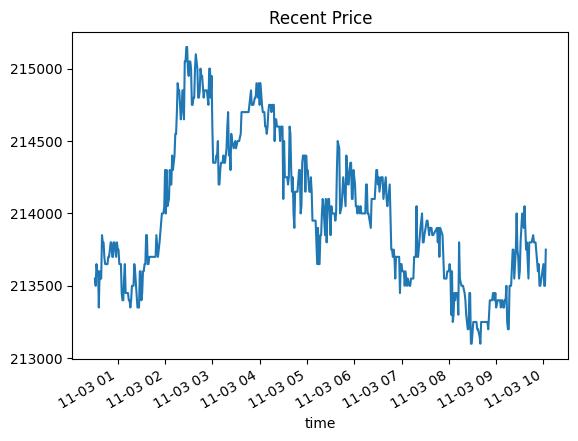

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# 데이터 불러오기
df = pd.read_csv('sub_upbit_eth_min_tick.csv', index_col=0, parse_dates=True)
labels = pd.read_pickle('sub_upbit_eth_min_tick_label.pkl')

# 결합 및 결측치 제거
df = df.join(labels).dropna()

# 라벨 정리 (XGBoost 학습을 위해 -1을 2로 변경)
# 0: 유지, 1: 상승, 2: 하락
df['target'] = df['t_value'].astype(int).replace(-1, 2)

# 데이터 시각화로 확인
df['close'].tail(500).plot(title='Recent Price')
plt.show()

In [11]:
def get_indicators(data):
    # 이동평균선 (추세 확인)
    data['ma5'] = data['close'].rolling(5).mean()
    data['ma20'] = data['close'].rolling(20).mean()

    # RSI (상대강도지수 - 과매수/과매도 확인)
    diff = data['close'].diff()
    up = diff.clip(lower=0).rolling(14).mean()
    down = -diff.clip(upper=0).rolling(14).mean()
    data['rsi'] = up / (up + down + 1e-9)

    # 변동성 및 가격 위치 지표
    data['volatility'] = data['high'] - data['low']
    data['max20'] = data['high'].rolling(20).max()
    data['min20'] = data['low'].rolling(20).min()
    data['price_pos'] = (data['close'] - data['min20']) / (data['max20'] - data['min20'] + 1e-9)

    return data.dropna()

df = get_indicators(df)

# 학습할 Feature 선택
features = ['open', 'high', 'low', 'close', 'volume', 'ma5', 'ma20', 'rsi', 'volatility', 'price_pos']
X = df[features]
y = df['target']

In [13]:
# 동일 조건에서 비교
from sklearn.model_selection import train_test_split

# 동일한 데이터 분할 (마지막 25%를 테스트로 고정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

# RandomForest 가격 데이터 5개만 사용
base_features = ['open', 'high', 'low', 'close', 'volume']
rf_base = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
rf_base.fit(X_train[base_features], y_train)
rf_acc = accuracy_score(y_test, rf_base.predict(X_test[base_features]))

# XGBoost 지표 10개 모두 사용
xgb_improved = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_improved.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb_improved.predict(X_test))

print(f"RandomForest(기본 가격만) 정확도: {rf_acc:.4f}")
print(f"XGBoost(지표 추가 및 튜닝) 정확도: {xgb_acc:.4f}")

RandomForest(기본 가격만) 정확도: 0.3299
XGBoost(지표 추가 및 튜닝) 정확도: 0.4514


RandomForest(기본 가격만) 정확도: 0.3299
XGBoost(지표 추가 및 튜닝) 정확도: 0.4514
최종 성능 향상률: 36.84% 향상


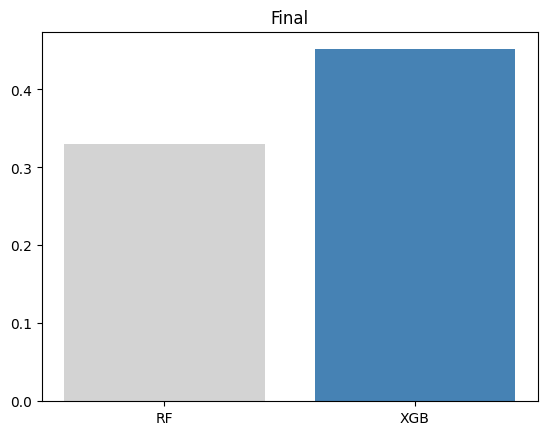

              precision    recall  f1-score   support

           0       0.33      0.25      0.28     69416
           1       0.48      0.53      0.50     76320
           2       0.50      0.55      0.52     81482

    accuracy                           0.45    227218
   macro avg       0.43      0.44      0.44    227218
weighted avg       0.44      0.45      0.44    227218



In [17]:
# 향상률 계산
improvement = (xgb_acc - rf_acc) / rf_acc * 100
print(f"RandomForest(기본 가격만) 정확도: {rf_acc:.4f}")
print(f"XGBoost(지표 추가 및 튜닝) 정확도: {xgb_acc:.4f}")
print(f"최종 성능 향상률: {improvement:.2f}% 향상")

# 막대 그래프로 시각화 비교
plt.bar(['RF', 'XGB'], [rf_acc, xgb_acc], color=['lightgray', 'steelblue'])
plt.title('Final')
plt.show()

# 상세 리포트
print(classification_report(y_test, xgb_improved.predict(X_test)))